# Analyse Qualité des Données : Consommation Électrique France

**Projet :** energy-data-quality  
**Source :** ODRE - Open Data Réseaux Énergies  
**Dataset :** Consommation quotidienne brute régionale  
**Date :** 2026-04-04

## Objectifs

1. Analyse exploratoire des données (EDA)
2. Évaluation de la qualité des données (complétude, cohérence, outliers)
3. Définition du modèle dimensionnel Kimball
4. Préparation des règles Great Expectations

---

## Imports

In [19]:
# Imports
import pandas as pd
import numpy as np
from pathlib import Path
import warnings

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Style des graphiques
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Imports OK")

✓ Imports OK


## Chargement des données

In [20]:
# Chemin vers le fichier CSV
DATA_PATH = Path("../data/raw/energy_data_20260404_202852.csv")

# Verification que le fichier existe
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Fichier introuvable: {DATA_PATH}")

print(f"Chargement des donnees depuis: {DATA_PATH}")
print(f"Taille du fichier: {DATA_PATH.stat().st_size / 1024 / 1024:.2f} MB")

# Chargement du CSV avec le bon separateur
df = pd.read_csv(DATA_PATH, sep=';', low_memory=False)

print(f"\n✓ Dataset charge: {len(df):,} lignes × {len(df.columns)} colonnes")

Chargement des donnees depuis: ../data/raw/energy_data_20260404_202852.csv
Taille du fichier: 270.25 MB

✓ Dataset charge: 2,768,823 lignes × 14 colonnes


## Aperçu des données

In [21]:
# Afficher les premieres lignes
print("=== APERÇU DES DONNÉES ===\n")
display(df.head(10))

print("\n=== DERNIÈRES LIGNES ===\n")
display(df.tail(5))

=== APERÇU DES DONNÉES ===



,Date - Heure,Date,Heure,Code INSEE région,Région,Consommation brute gaz (MW PCS 0°C) - NaTran,Statut - NaTran,Consommation brute gaz (MW PCS 0°C) - Teréga,Statut - Teréga,Consommation brute gaz totale (MW PCS 0°C),Consommation brute électricité (MW) - RTE,Statut - RTE,Consommation brute totale (MW),flag_ignore
0,2015-05-05T00:00:00+02:00,2015-05-05,00:00,44,Grand Est,4210.0,Définitif,NaN,NaN,4210.0,4765.0,Définitif,8975.0,non
1,2015-05-05T00:00:00+02:00,2015-05-05,00:00,53,Bretagne,1026.0,Définitif,NaN,NaN,1026.0,2733.0,Définitif,3759.0,non
2,2015-05-05T00:00:00+02:00,2015-05-05,00:00,76,Occitanie,327.0,Définitif,645.0,Définitif,972.0,3879.0,Définitif,4851.0,non
3,2015-05-05T00:30:00+02:00,2015-05-05,00:30,24,Centre-Val de Loire,NaN,NaN,NaN,NaN,NaN,1861.0,Définitif,NaN,non
4,2015-05-05T00:30:00+02:00,2015-05-05,00:30,32,Hauts-de-France,NaN,NaN,NaN,NaN,NaN,5504.0,Définitif,NaN,non
5,2015-05-05T00:30:00+02:00,2015-05-05,00:30,84,Auvergne-Rhône-Alpes,NaN,NaN,NaN,NaN,NaN,6398.0,Définitif,NaN,non
6,2015-05-05T01:00:00+02:00,2015-05-05,01:00,44,Grand Est,4167.0,Définitif,NaN,NaN,4167.0,4447.0,Définitif,8614.0,non
7,2015-05-05T01:30:00+02:00,2015-05-05,01:30,11,Île-de-France,NaN,NaN,NaN,NaN,NaN,6031.0,Définitif,NaN,non
8,2015-05-05T01:30:00+02:00,2015-05-05,01:30,24,Centre-Val de Loire,NaN,NaN,NaN,NaN,NaN,1834.0,Définitif,NaN,non
9,2015-05-05T01:30:00+02:00,2015-05-05,01:30,76,Occitanie,NaN,NaN,NaN,NaN,NaN,3018.0,Définitif,NaN,non



=== DERNIÈRES LIGNES ===



,Date - Heure,Date,Heure,Code INSEE région,Région,Consommation brute gaz (MW PCS 0°C) - NaTran,Statut - NaTran,Consommation brute gaz (MW PCS 0°C) - Teréga,Statut - Teréga,Consommation brute gaz totale (MW PCS 0°C),Consommation brute électricité (MW) - RTE,Statut - RTE,Consommation brute totale (MW),flag_ignore
2768818,2026-02-28T22:30:00+01:00,2026-02-28,22:30,93,Provence-Alpes-Côte d'Azur,NaN,NaN,NaN,NaN,NaN,4659.0,Consolidé,NaN,non
2768819,2026-02-28T23:00:00+01:00,2026-02-28,23:00,53,Bretagne,1525.0,Définitif,NaN,NaN,1525.0,2555.0,Consolidé,4080.0,non
2768820,2026-02-28T23:30:00+01:00,2026-02-28,23:30,24,Centre-Val de Loire,NaN,NaN,NaN,NaN,NaN,2210.0,Consolidé,NaN,non
2768821,2026-02-28T23:30:00+01:00,2026-02-28,23:30,53,Bretagne,NaN,NaN,NaN,NaN,NaN,2712.0,Consolidé,NaN,non
2768822,2026-02-28T23:30:00+01:00,2026-02-28,23:30,75,Nouvelle-Aquitaine,NaN,NaN,NaN,NaN,NaN,5073.0,Consolidé,NaN,non


## Informations générales

In [22]:
# Informations sur le dataset
print("=== INFORMATIONS GÉNÉRALES ===\n")
df.info()

print("\n=== TYPES DE DONNÉES ===")
print(df.dtypes)

=== INFORMATIONS GÉNÉRALES ===

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2768823 entries, 0 to 2768822
Data columns (total 14 columns):
 #   Column                                        Dtype  
---  ------                                        -----  
 0   Date - Heure                                  object 
 1   Date                                          object 
 2   Heure                                         object 
 3   Code INSEE région                             int64  
 4   Région                                        object 
 5   Consommation brute gaz (MW PCS 0°C) - NaTran  float64
 6   Statut - NaTran                               object 
 7   Consommation brute gaz (MW PCS 0°C) - Teréga  float64
 8   Statut - Teréga                               object 
 9   Consommation brute gaz totale (MW PCS 0°C)    float64
 10  Consommation brute électricité (MW) - RTE     float64
 11  Statut - RTE                                  object 
 12  Consommation brute total

## Statistiques descriptives

In [23]:
# Statistiques descriptives sur les colonnes numeriques
print("=== STATISTIQUES DESCRIPTIVES ===\n")
display(df.describe())

print("\n=== VALEURS UNIQUES PAR COLONNE ===")
for col in df.columns:
    n_unique = df[col].nunique()
    print(f"{col:50} : {n_unique:>8} valeurs uniques")

=== STATISTIQUES DESCRIPTIVES ===



,Code INSEE région,Consommation brute gaz (MW PCS 0°C) - NaTran,Consommation brute gaz (MW PCS 0°C) - Teréga,Consommation brute gaz totale (MW PCS 0°C),Consommation brute électricité (MW) - RTE,Consommation brute totale (MW)
count,2.768823e+06,1.384340e+06,346104.000000,1.384339e+06,2.768820e+06,1.384339e+06
mean,4.991670e+01,3.906407e+03,1001.911007,4.156877e+03,4.409057e+03,8.566447e+03
std,2.564001e+01,3.630884e+03,1069.935146,3.534891e+03,2.122535e+03,5.296184e+03
min,1.100000e+01,0.000000e+00,1.000000,0.000000e+00,-3.239000e+03,1.175000e+03
25%,2.800000e+01,1.267000e+03,44.000000,1.668000e+03,2.731000e+03,4.889000e+03
50%,5.200000e+01,2.875000e+03,650.000000,3.184000e+03,4.051000e+03,7.280000e+03
75%,7.600000e+01,5.129000e+03,1659.000000,5.358000e+03,5.614000e+03,1.065100e+04
max,9.300000e+01,5.875800e+04,5746.000000,5.875800e+04,1.533800e+04,6.969900e+04



=== VALEURS UNIQUES PAR COLONNE ===
Date - Heure                                       :   230710 valeurs uniques
Date                                               :     4807 valeurs uniques
Heure                                              :       48 valeurs uniques
Code INSEE région                                  :       12 valeurs uniques
Région                                             :       12 valeurs uniques
Consommation brute gaz (MW PCS 0°C) - NaTran       :    21873 valeurs uniques
Statut - NaTran                                    :        2 valeurs uniques
Consommation brute gaz (MW PCS 0°C) - Teréga       :     5021 valeurs uniques
Statut - Teréga                                    :        2 valeurs uniques
Consommation brute gaz totale (MW PCS 0°C)         :    21830 valeurs uniques
Consommation brute électricité (MW) - RTE          :    13363 valeurs uniques
Statut - RTE                                       :        2 valeurs uniques
Consommation brute totale (

## Analyse des valeurs manquantes

=== VALEURS MANQUANTES ===



,Colonne,Valeurs manquantes,Pourcentage
7,Consommation brute gaz (MW PCS 0°C) - Teréga,2422719,87.499959
8,Statut - Teréga,2422718,87.499923
9,Consommation brute gaz totale (MW PCS 0°C),1384484,50.002618
12,Consommation brute totale (MW),1384484,50.002618
5,Consommation brute gaz (MW PCS 0°C) - NaTran,1384483,50.002582
6,Statut - NaTran,1384479,50.002438
11,Statut - RTE,17859,0.645003
10,Consommation brute électricité (MW) - RTE,3,0.000108


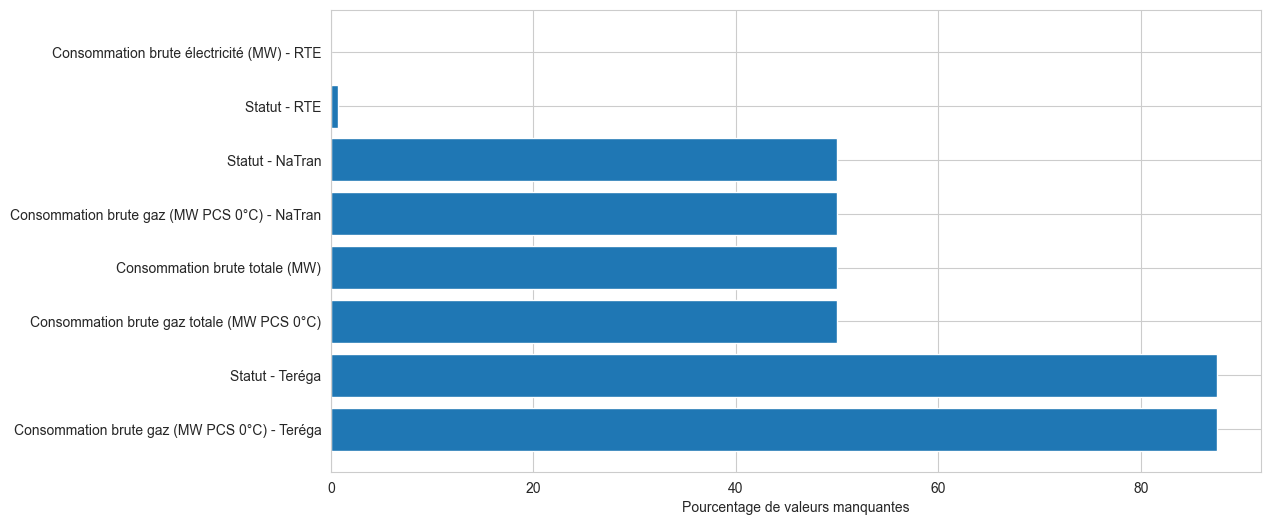

In [24]:
# Analyse des valeurs manquantes
print("=== VALEURS MANQUANTES ===\n")

missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Colonne': missing.index,
    'Valeurs manquantes': missing.values,
    'Pourcentage': missing_pct.values
})

missing_df = missing_df[missing_df['Valeurs manquantes'] > 0].sort_values('Valeurs manquantes', ascending=False)

if len(missing_df) > 0:
    display(missing_df)
    
    # Visualisation
    plt.figure(figsize=(12, 6))
    plt.barh(missing_df['Colonne'], missing_df['Pourcentage'])
    plt.xlabel('Pourcentage de valeurs manquantes')
    plt

## Analyse des régions

=== ANALYSE RÉGIONALE ===

Nombre de régions: 12



,Code INSEE région,Région,Nombre_observations
8,75,Nouvelle-Aquitaine,230736
9,76,Occitanie,230736
10,84,Auvergne-Rhône-Alpes,230736
0,11,Île-de-France,230735
1,24,Centre-Val de Loire,230735
2,27,Bourgogne-Franche-Comté,230735
3,28,Normandie,230735
4,32,Hauts-de-France,230735
5,44,Grand Est,230735
6,52,Pays de la Loire,230735


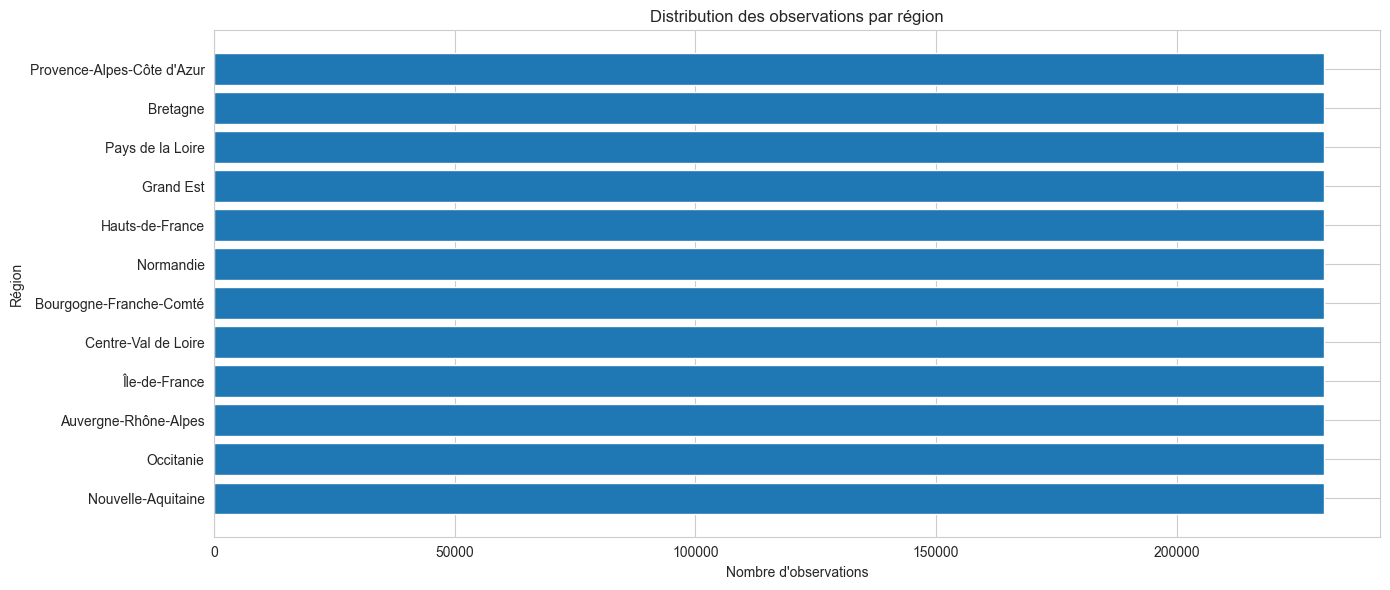

In [25]:
# Analyse de la couverture regionale
print("=== ANALYSE RÉGIONALE ===\n")

regions = df.groupby(['Code INSEE région', 'Région']).size().reset_index(name='Nombre_observations')
regions = regions.sort_values('Nombre_observations', ascending=False)

print(f"Nombre de régions: {len(regions)}\n")
display(regions)

# Visualisation
plt.figure(figsize=(14, 6))
plt.barh(regions['Région'], regions['Nombre_observations'])
plt.xlabel('Nombre d\'observations')
plt.ylabel('Région')
plt.title('Distribution des observations par région')
plt.tight_layout()
plt.show()

## Analyse temporelle

In [26]:
# Conversion de la colonne Date en datetime
print("=== ANALYSE TEMPORELLE ===\n")

df['Date_parsed'] = pd.to_datetime(df['Date'], format='%Y-%m-%d', errors='coerce')

print(f"Période couverte:")
print(f"  - Début: {df['Date_parsed'].min()}")
print(f"  - Fin:   {df['Date_parsed'].max()}")
print(f"  - Durée: {(df['Date_parsed'].max() - df['Date_parsed'].min()).days} jours")

print(f"\nNombre de dates uniques: {df['Date_parsed'].nunique()}")
print(f"Nombre d'heures uniques: {df['Heure'].nunique()}")

# Valeurs uniques de l'heure
print(f"\nHeures présentes dans le dataset:")
print(sorted(df['Heure'].unique()))

=== ANALYSE TEMPORELLE ===

Période couverte:
  - Début: 2013-01-01 00:00:00
  - Fin:   2026-02-28 00:00:00
  - Durée: 4806 jours

Nombre de dates uniques: 4807
Nombre d'heures uniques: 48

Heures présentes dans le dataset:
['00:00', '00:30', '01:00', '01:30', '02:00', '02:30', '03:00', '03:30', '04:00', '04:30', '05:00', '05:30', '06:00', '06:30', '07:00', '07:30', '08:00', '08:30', '09:00', '09:30', '10:00', '10:30', '11:00', '11:30', '12:00', '12:30', '13:00', '13:30', '14:00', '14:30', '15:00', '15:30', '16:00', '16:30', '17:00', '17:30', '18:00', '18:30', '19:00', '19:30', '20:00', '20:30', '21:00', '21:30', '22:00', '22:30', '23:00', '23:30']


## Analyse des outliers - Électricité

=== ANALYSE OUTLIERS - CONSOMMATION ÉLECTRICITÉ ===

count    2.768820e+06
mean     4.409057e+03
std      2.122535e+03
min     -3.239000e+03
25%      2.731000e+03
50%      4.051000e+03
75%      5.614000e+03
max      1.533800e+04
Name: Consommation brute électricité (MW) - RTE, dtype: float64

Outliers détectés:
  - Borne inférieure: -1593.50 MW
  - Borne supérieure: 9938.50 MW
  - Nombre d'outliers: 57,992 (2.09%)


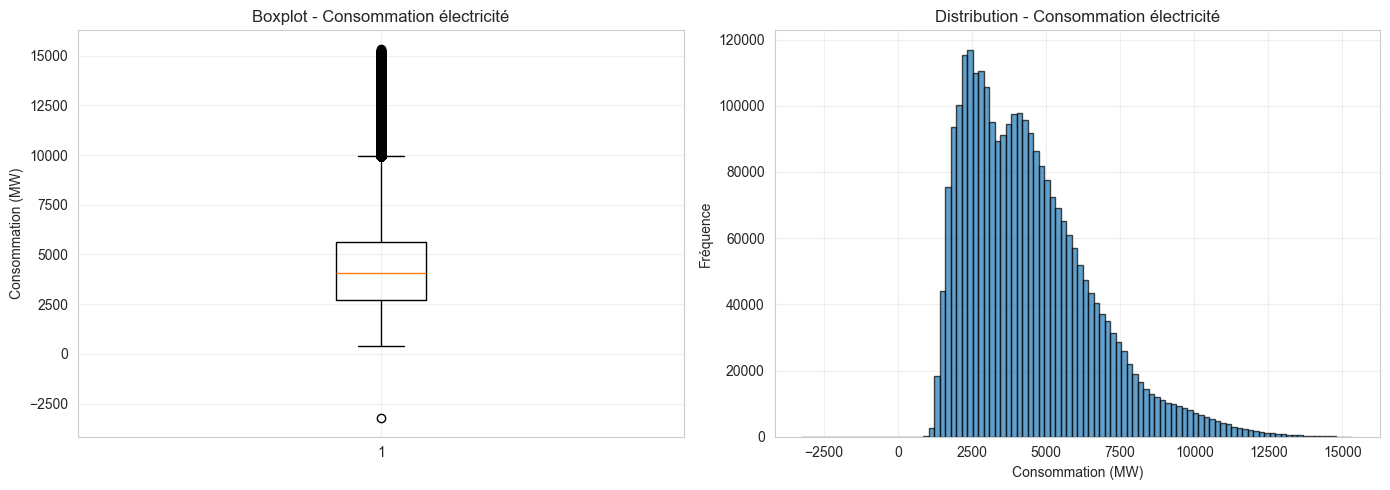

In [27]:
# Analyse des outliers sur la consommation electrique
print("=== ANALYSE OUTLIERS - CONSOMMATION ÉLECTRICITÉ ===\n")

elec_col = 'Consommation brute électricité (MW) - RTE'

# Statistiques
stats = df[elec_col].describe()
print(stats)

# Detection outliers avec IQR (Interquartile Range)
Q1 = df[elec_col].quantile(0.25)
Q3 = df[elec_col].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df[elec_col] < lower_bound) | (df[elec_col] > upper_bound)]

print(f"\nOutliers détectés:")
print(f"  - Borne inférieure: {lower_bound:.2f} MW")
print(f"  - Borne supérieure: {upper_bound:.2f} MW")
print(f"  - Nombre d'outliers: {len(outliers):,} ({len(outliers)/len(df)*100:.2f}%)")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
axes[0].boxplot(df[elec_col].dropna())
axes[0].set_ylabel('Consommation (MW)')
axes[0].set_title('Boxplot - Consommation électricité')
axes[0].grid(True, alpha=0.3)

# Histogramme
axes[1].hist(df[elec_col].dropna(), bins=100, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Consommation (MW)')
axes[1].set_ylabel('Fréquence')
axes[1].set_title('Distribution - Consommation électricité')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Analyse des valeurs négatives

In [28]:
# Analyse des valeurs negatives
print("=== ANALYSE DES VALEURS NÉGATIVES ===\n")

negative = df[df[elec_col] < 0]

print(f"Nombre de valeurs négatives: {len(negative):,} ({len(negative)/len(df)*100:.4f}%)")

if len(negative) > 0:
    print(f"\nStatistiques des valeurs négatives:")
    print(negative[elec_col].describe())
    
    print(f"\nRépartition par région:")
    print(negative.groupby('Région').size().sort_values(ascending=False))
    
    print(f"\nExemples de lignes avec valeurs négatives:")
    display(negative[['Date', 'Heure', 'Région', elec_col, 'Statut - RTE']].head(10))

=== ANALYSE DES VALEURS NÉGATIVES ===

Nombre de valeurs négatives: 1 (0.0000%)

Statistiques des valeurs négatives:
count       1.0
mean    -3239.0
std         NaN
min     -3239.0
25%     -3239.0
50%     -3239.0
75%     -3239.0
max     -3239.0
Name: Consommation brute électricité (MW) - RTE, dtype: float64

Répartition par région:
Région
Auvergne-Rhône-Alpes    1
dtype: int64

Exemples de lignes avec valeurs négatives:


,Date,Heure,Région,Consommation brute électricité (MW) - RTE,Statut - RTE
2552716,2025-11-13,11:30,Auvergne-Rhône-Alpes,-3239.0,Consolidé


## Analyse de la colonne Statut

In [29]:
# Analyse des statuts de validation
print("=== ANALYSE DES STATUTS DE VALIDATION ===\n")

for col in ['Statut - RTE', 'Statut - NaTran', 'Statut - Teréga']:
    print(f"\n{col}:")
    print(df[col].value_counts(dropna=False))
    print(f"  → {df[col].notna().sum():,} valeurs ({df[col].notna().sum()/len(df)*100:.2f}%)")

=== ANALYSE DES STATUTS DE VALIDATION ===


Statut - RTE:
Statut - RTE
Définitif    1472244
Consolidé    1278720
NaN            17859
Name: count, dtype: int64
  → 2,750,964 valeurs (99.35%)

Statut - NaTran:
Statut - NaTran
NaN          1384479
Définitif    1279224
Redressé      105120
Name: count, dtype: int64
  → 1,384,344 valeurs (50.00%)

Statut - Teréga:
Statut - Teréga
NaN          2422718
Définitif     346104
vers               1
Name: count, dtype: int64
  → 346,105 valeurs (12.50%)


## Focus sur l'électricité - Évolution temporelle

=== ÉVOLUTION TEMPORELLE - CONSOMMATION ÉLECTRICITÉ ===

Consommation moyenne journalière:
count    4807.000000
mean     4409.057925
std       885.678952
min      2938.137153
25%      3725.416667
50%      4124.869792
75%      5071.693576
max      7466.645833
Name: Consommation_moyenne_MW, dtype: float64


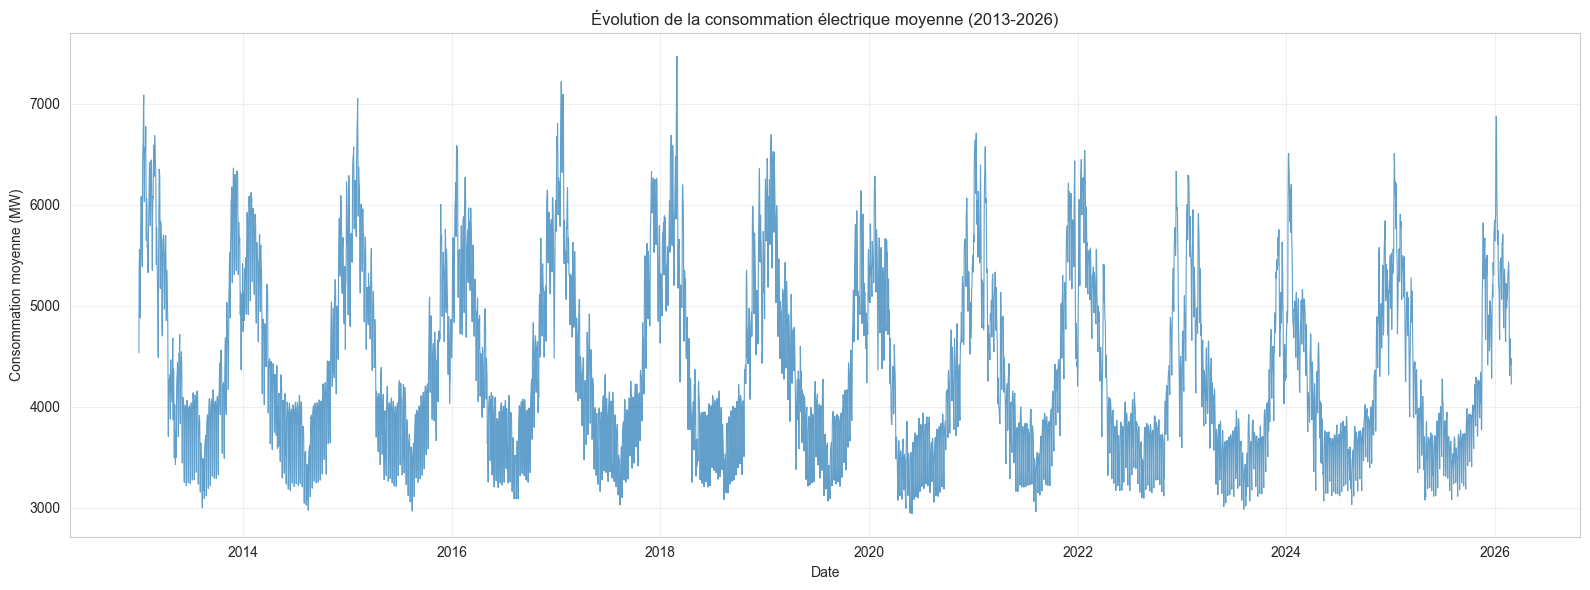


=== CONSOMMATION MOYENNE PAR ANNÉE ===


,Annee,Consommation brute électricité (MW) - RTE
0,2013,4681.271110
1,2014,4398.293170
2,2015,4501.073630
3,2016,4556.727174
4,2017,4557.122555
5,2018,4523.601593
6,2019,4475.620015
7,2020,4227.553763
8,2021,4444.410459
9,2022,4276.965558


In [30]:
# Evolution temporelle de la consommation electrique
print("=== ÉVOLUTION TEMPORELLE - CONSOMMATION ÉLECTRICITÉ ===\n")

# Agregation journaliere (moyenne)
daily = df.groupby('Date_parsed')[elec_col].mean().reset_index()
daily.columns = ['Date', 'Consommation_moyenne_MW']

print(f"Consommation moyenne journalière:")
print(daily['Consommation_moyenne_MW'].describe())

# Visualisation
plt.figure(figsize=(16, 6))
plt.plot(daily['Date'], daily['Consommation_moyenne_MW'], linewidth=0.8, alpha=0.7)
plt.xlabel('Date')
plt.ylabel('Consommation moyenne (MW)')
plt.title('Évolution de la consommation électrique moyenne (2013-2026)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Analyse par annee
df['Annee'] = df['Date_parsed'].dt.year
yearly = df.groupby('Annee')[elec_col].mean().reset_index()

print(f"\n=== CONSOMMATION MOYENNE PAR ANNÉE ===")
display(yearly)

---

## 📊 SYNTHÈSE QUALITÉ DES DONNÉES

### ✅ Points positifs

- **Volume** : 2,7M lignes, 13 ans de données (2013-2026)
- **Cohérence régionale** : 13 régions avec exactement le même nombre d'observations
- **Granularité** : 30 minutes (48 créneaux/jour)
- **Complétude électricité** : 99,9% (3 valeurs manquantes seulement)
- **Validation** : 99,35% des données RTE validées (Définitif ou Consolidé)

### ⚠️ Problématiques identifiées

| Problème | Gravité | Volume | Action |
|----------|---------|--------|--------|
| **Valeurs manquantes gaz Teréga** | Moyenne | 87,5% | Exclure ou imputer |
| **Valeurs manquantes gaz NaTran** | Moyenne | 50% | Analyser distribution géographique |
| **Valeur négative électricité** | Critique | 1 ligne | Correction manuelle |
| **Outliers électricité** | Faible | 2,09% | Validation métier (pics réels ?) |
| **Données 2026 incomplètes** | Info | 2 mois | Exclusion des analyses tendancielles |

### 🎯 Décisions pour la suite

1. **Focus sur l'électricité** (données RTE) : complétude et qualité excellentes
2. **Correction manuelle** de la valeur négative
3. **Exclusion 2026** pour les analyses temporelles (données partielles)
4. **Modélisation Kimball** centrée sur la consommation électrique

---